# 01 — Exploratory Data Analysis (MSTAR SAR)

**Goal:** classify 10 military vehicles from Synthetic Aperture Radar (SAR) imagery
(MSTAR SOC benchmark). This notebook explores the dataset and computes the
normalization statistics (`dataset_stats.json`) consumed by the deep-learning notebooks.
Outputs are written to `results/eda/`.

In [1]:
import os, sys, json, time
import numpy as np
import pandas as pd
# Make the project root importable whether run from notebooks/ or the project root.
cwd = os.getcwd()
ROOT = cwd if os.path.isdir(os.path.join(cwd, "src")) else os.path.dirname(cwd)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
from src.dataset import PROJECT_ROOT
from src.evaluate import seed_everything
from IPython.display import Image, display, Markdown
seed_everything(42)

from src.dataset import CLASSES, TRAIN_DIR, TEST_DIR, scan_samples, stratified_split
from src.evaluate import save_json
from src import eda_viz
EDA_DIR = os.path.join(PROJECT_ROOT, "results", "eda")
os.makedirs(EDA_DIR, exist_ok=True)
print("Project root :", PROJECT_ROOT)
print("EDA outputs  :", EDA_DIR)

Project root : C:\Users\Ali\Desktop\asel_proje_v2
EDA outputs  : C:\Users\Ali\Desktop\asel_proje_v2\results\eda


## Load training images and the stratified split

In [2]:
train_samples = scan_samples(TRAIN_DIR)
test_samples = scan_samples(TEST_DIR)
train_s, val_s = stratified_split(train_samples)
print(f"Train(full)={len(train_samples)}  Train={len(train_s)}  Val={len(val_s)}  Test={len(test_samples)}")
imgs, labels = eda_viz.load_images(train_samples)
train_counts = [int((labels == i).sum()) for i in range(len(CLASSES))]
test_labels = np.array([l for _, l in test_samples])
test_counts = [int((test_labels == i).sum()) for i in range(len(CLASSES))]
print("image tensor:", imgs.shape)

Train(full)=2747  Train=2334  Val=413  Test=2425


image tensor: (2747, 128, 128)


## Class distribution (train vs test)

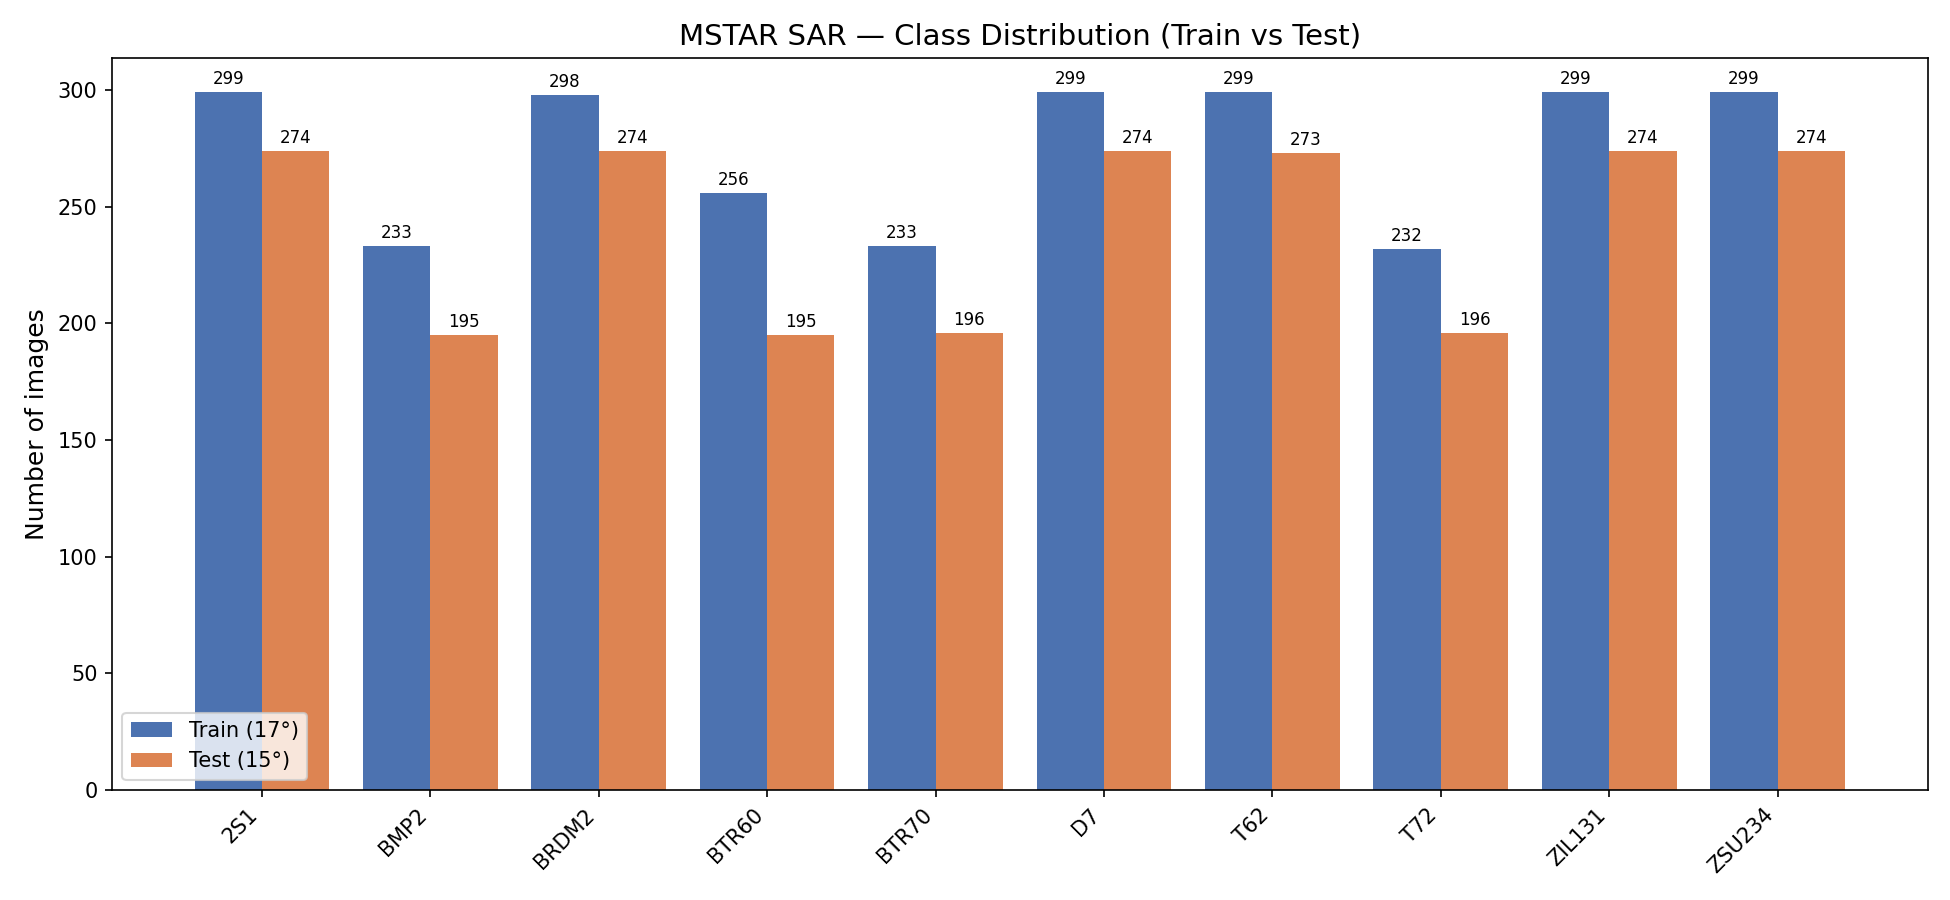

In [3]:
p = os.path.join(EDA_DIR, "eda_class_distribution.png")
eda_viz.plot_class_distribution(train_counts, test_counts, p)
display(Image(filename=p))

## Sample images per class

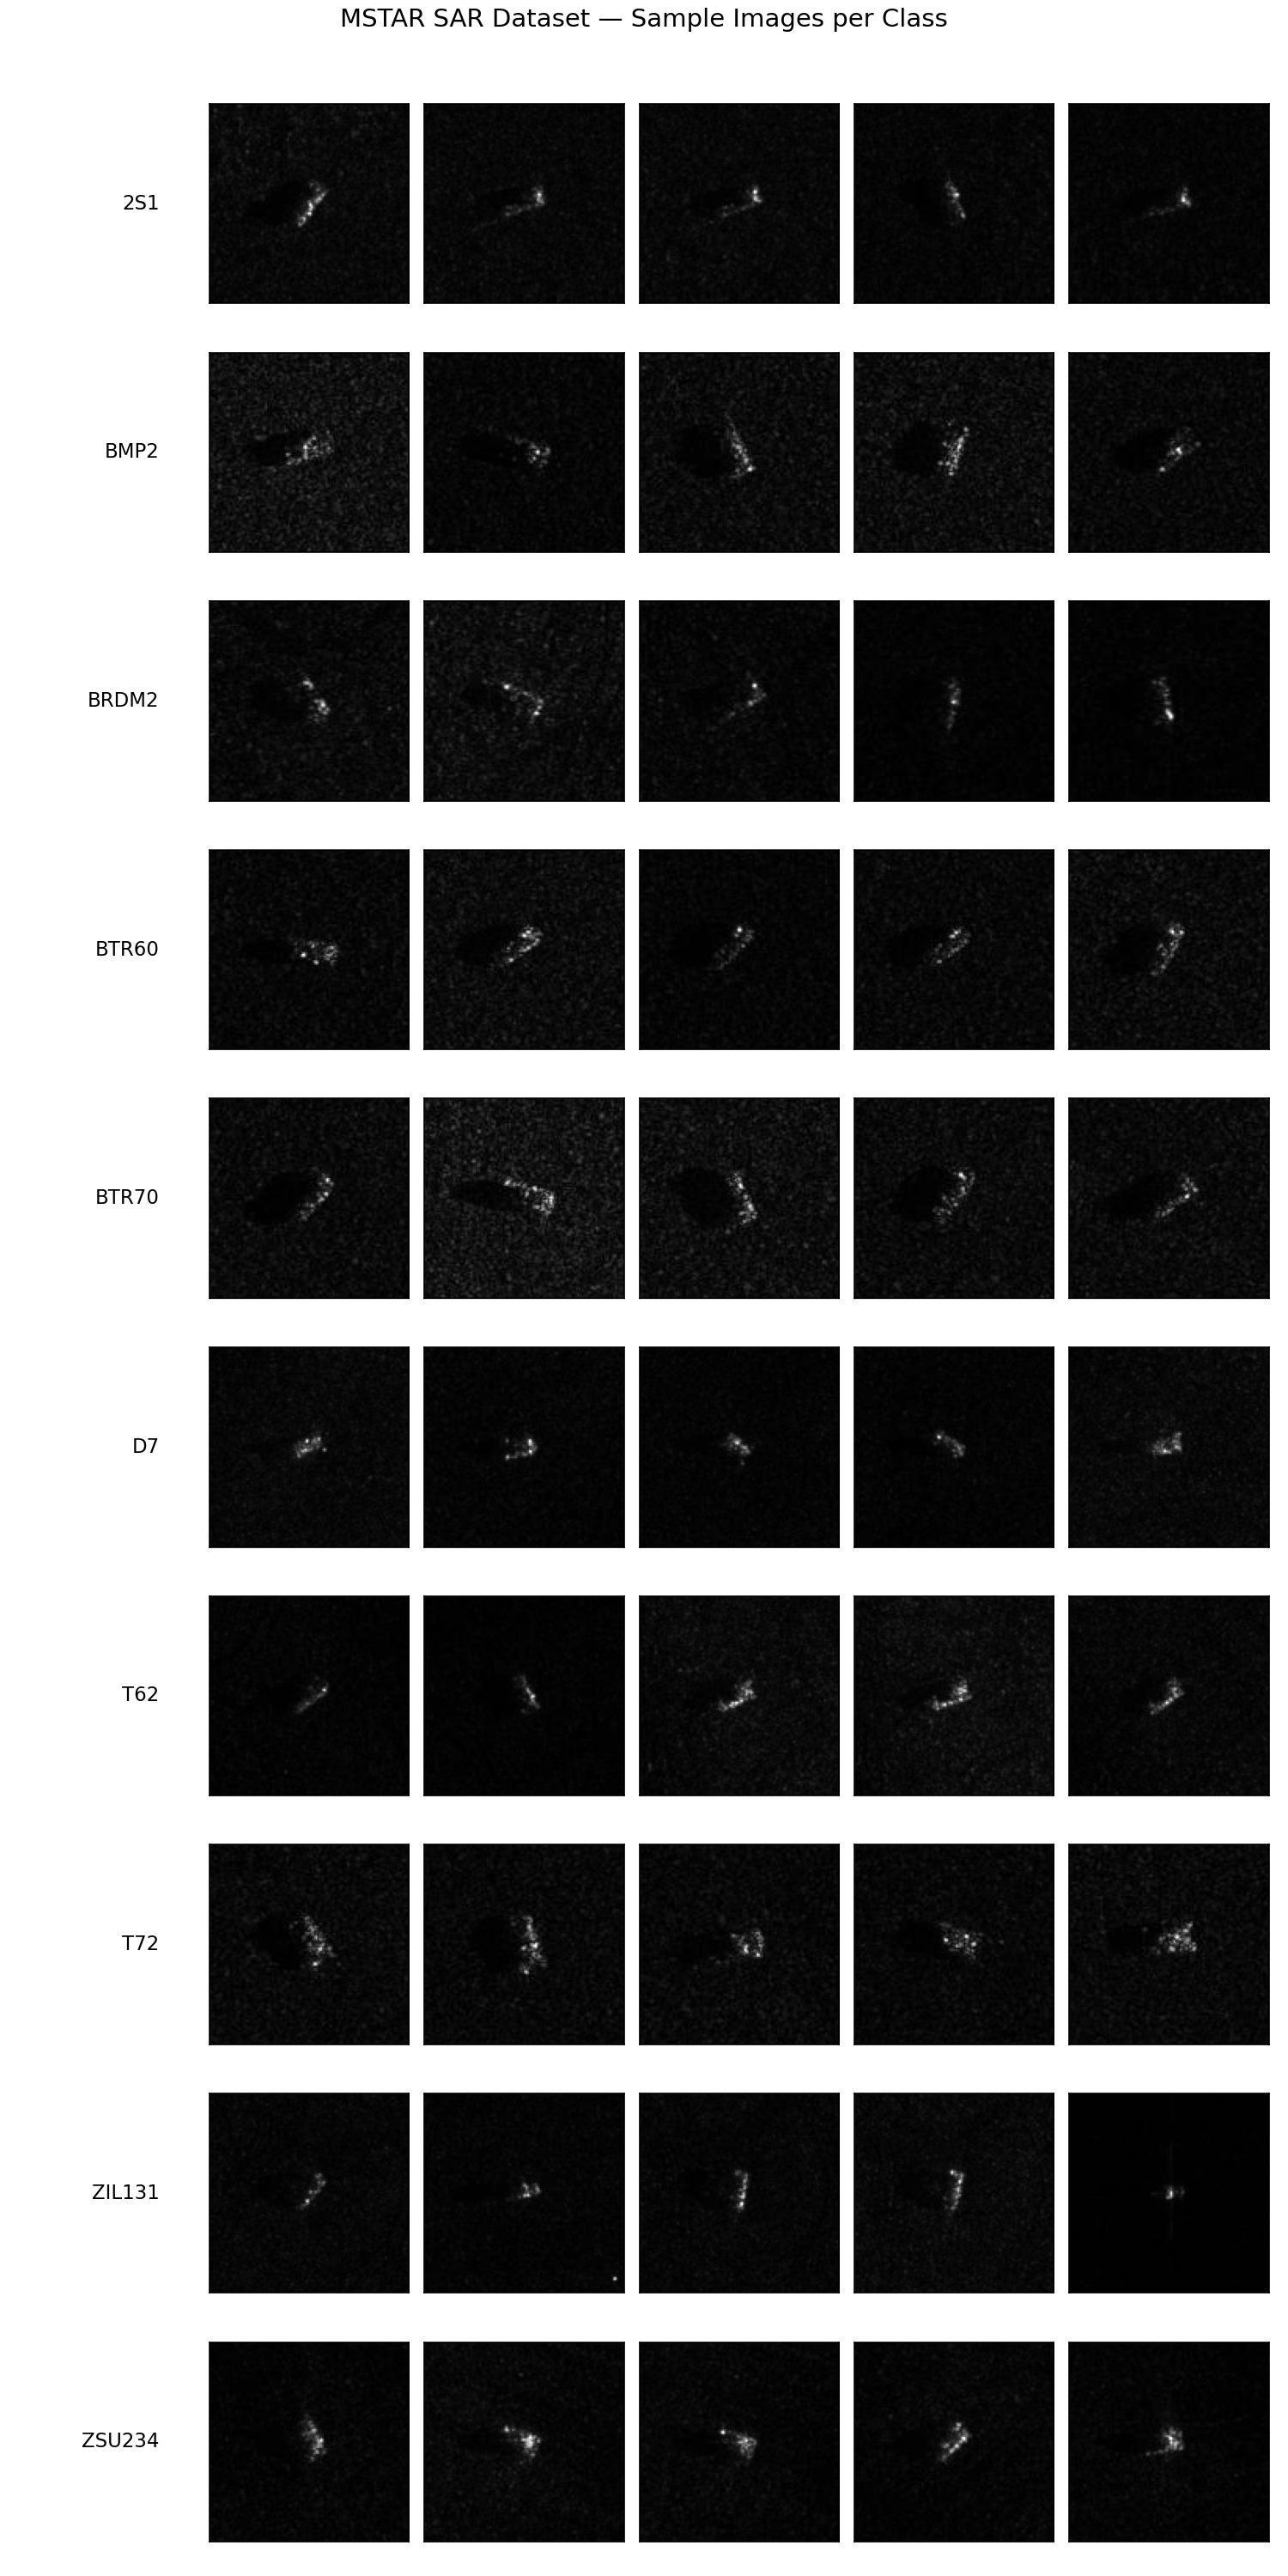

In [4]:
rng = np.random.default_rng(42)
p = os.path.join(EDA_DIR, "eda_sample_images.png")
eda_viz.plot_sample_images(imgs, labels, p, rng)
display(Image(filename=p))

## Per-class pixel intensity distribution

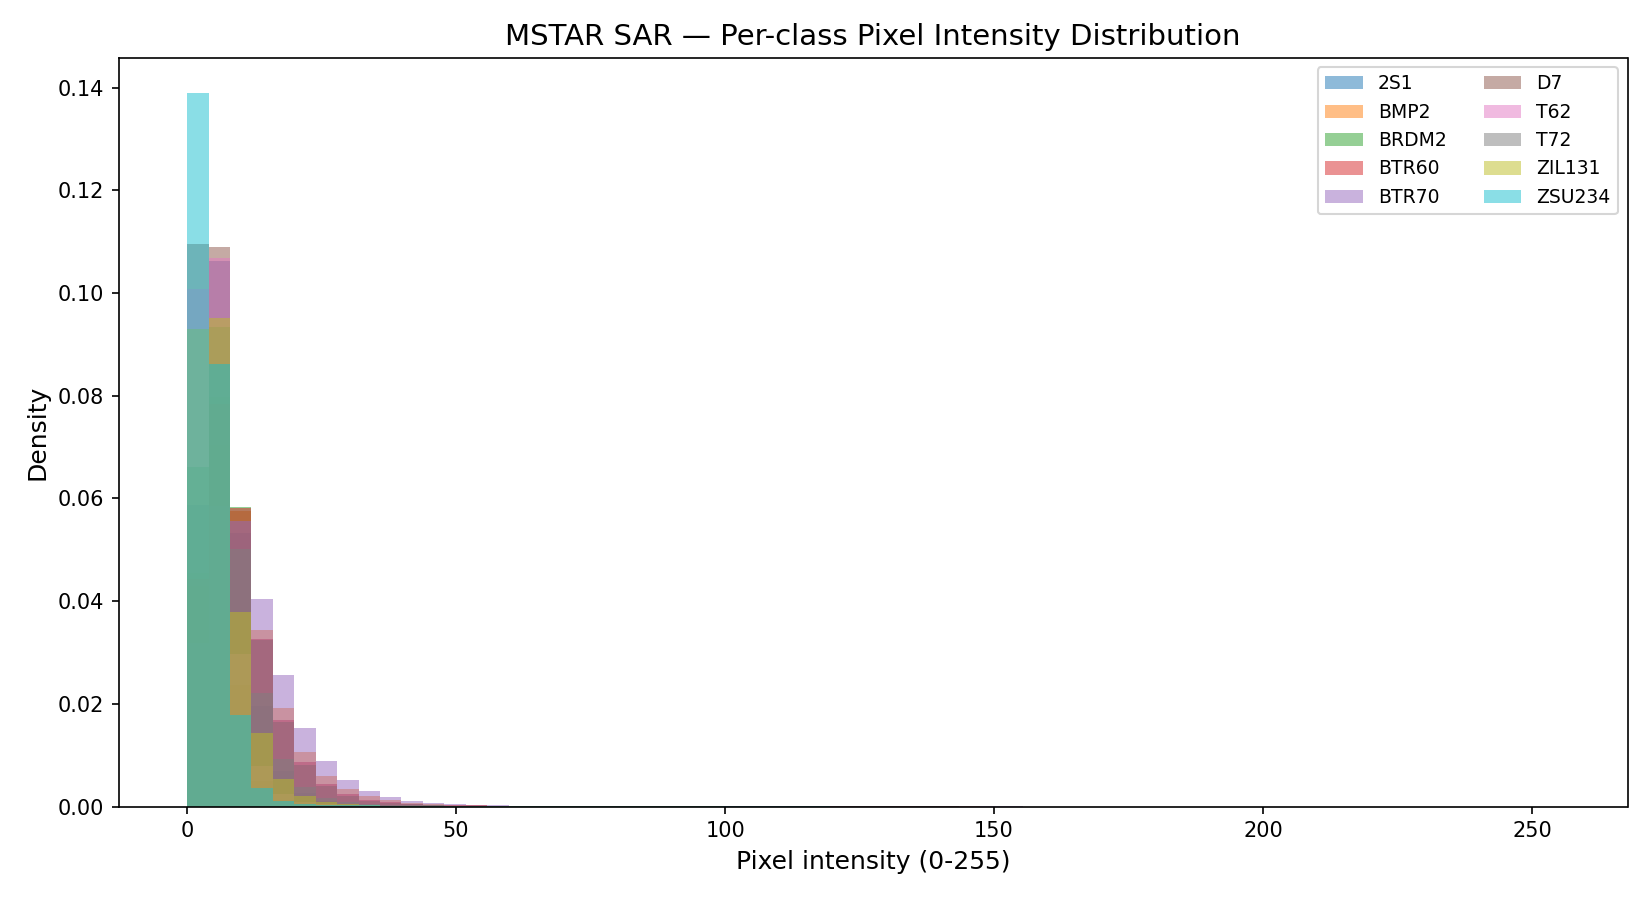

In [5]:
p = os.path.join(EDA_DIR, "eda_pixel_intensity.png")
eda_viz.plot_pixel_intensity(imgs, labels, p)
display(Image(filename=p))

## Per-class mean image

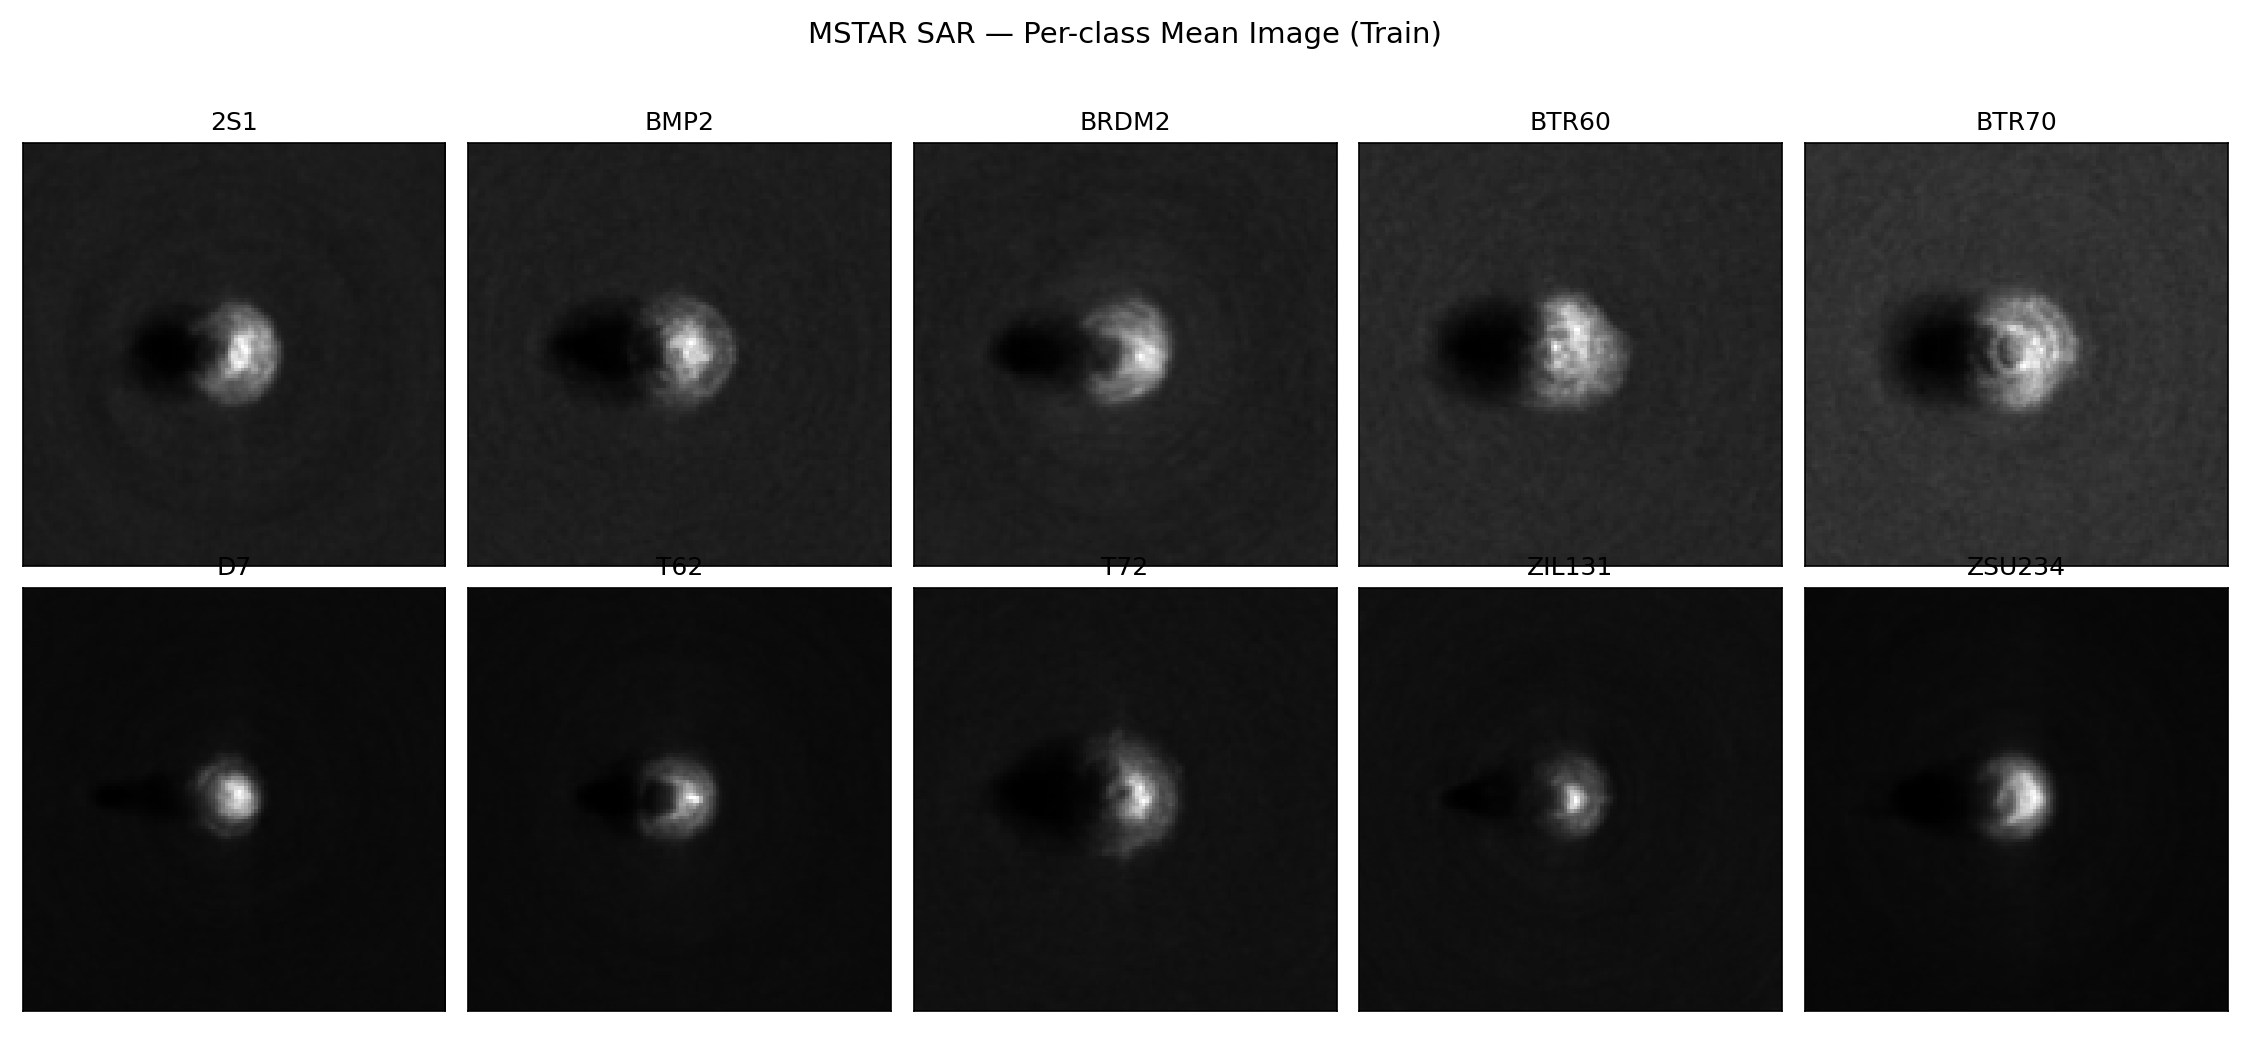

In [6]:
p = os.path.join(EDA_DIR, "eda_mean_images.png")
eda_viz.plot_mean_images(imgs, labels, p)
display(Image(filename=p))

## t-SNE of raw pixels (PCA-50 → t-SNE)

Running PCA-50 -> t-SNE on raw pixels (this can take ~1 min)...


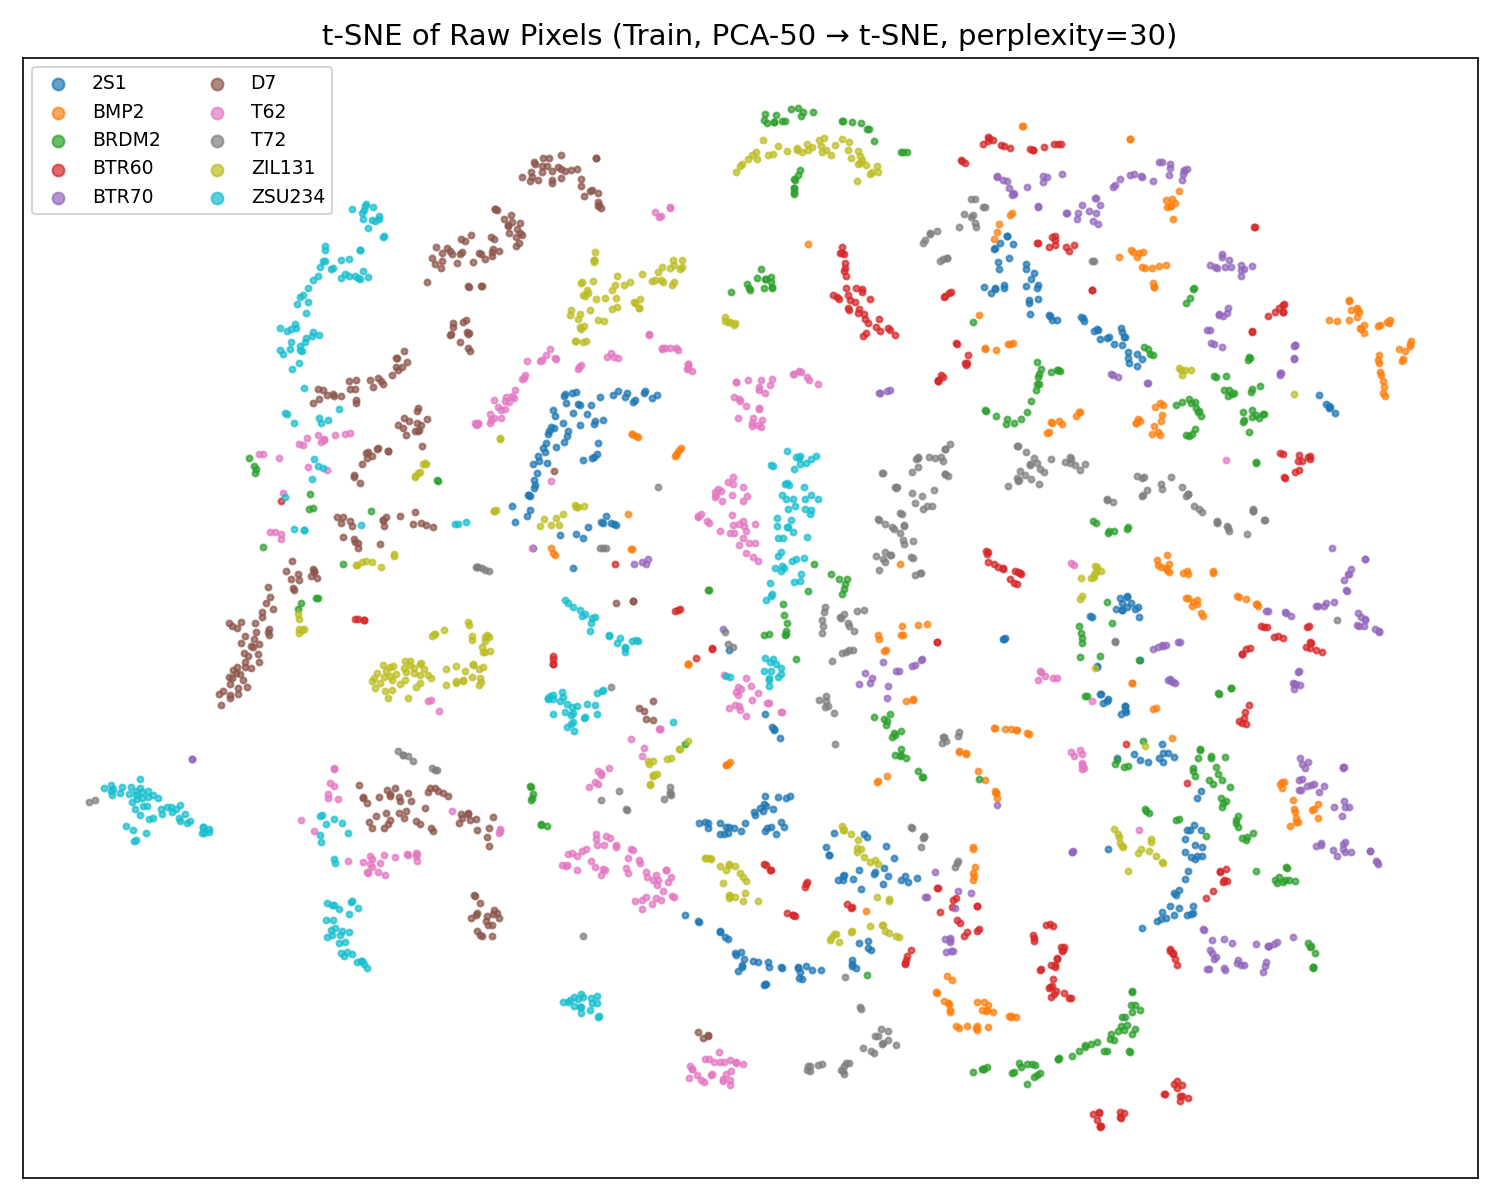

In [7]:
p = os.path.join(EDA_DIR, "eda_tsne_raw.png")
npy = os.path.join(EDA_DIR, "tsne_raw_train.npy")
eda_viz.plot_tsne_raw(imgs, labels, p, npy)
display(Image(filename=p))

## Dataset statistics & normalization constants

In [8]:
pixel_mean = float(imgs.astype(np.float64).mean() / 255.0)
pixel_std = float(imgs.astype(np.float64).std() / 255.0)
stats = {
    "image_size": [128, 128],
    "n_train_full": len(train_samples),
    "n_train": len(train_s),
    "n_val": len(val_s),
    "n_test": len(test_samples),
    "per_class_train": {c: train_counts[i] for i, c in enumerate(CLASSES)},
    "per_class_test": {c: test_counts[i] for i, c in enumerate(CLASSES)},
    "pixel_mean": pixel_mean,
    "pixel_std": pixel_std,
    "pixel_min": int(imgs.min()),
    "pixel_max": int(imgs.max()),
}
save_json(stats, os.path.join(EDA_DIR, "dataset_stats.json"))
print(f"pixel_mean={pixel_mean:.4f}  pixel_std={pixel_std:.4f}")
display(pd.DataFrame({"train": stats["per_class_train"], "test": stats["per_class_test"]}))

pixel_mean=0.0295  pixel_std=0.0346


,train,test
2S1,299,274
BMP2,233,195
BRDM2,298,274
BTR60,256,195
BTR70,233,196
D7,299,274
T62,299,273
T72,232,196
ZIL131,299,274
ZSU234,299,274
